In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
# --- Configuration ---
DATASET_PATH = "./dataset/cancer (1).csv"
TARGET_COLUMN = "diagnosis"
DROP_COLUMN = "id"
TEST_SIZE = 0.15
RANDOM_STATE = 42

In [3]:
# --- Load Data ---
try:
    data = pd.read_csv(DATASET_PATH)
except FileNotFoundError:
    print(f"Error: Dataset not found at {DATASET_PATH}")
    exit() # Exit if the dataset file is not found

In [4]:
# --- Data Preprocessing ---
# Display first few rows and basic statistics
print("Dataset Head:")
print(data.head())
print("\nDataset Description:")
print(data.describe())

# Drop unnecessary columns (like 'id')
if DROP_COLUMN in data.columns:
    data = data.drop([DROP_COLUMN], axis=1)
else:
    print(f"Warning: Column '{DROP_COLUMN}' not found in dataset.")

# Convert target column to numerical (M=1 for malignant, B=0 for benign)
if TARGET_COLUMN in data.columns:
    data[TARGET_COLUMN] = data[TARGET_COLUMN].apply(lambda diagnosis: 1 if diagnosis == "M" else 0)
else:
    print(f"Error: Target column '{TARGET_COLUMN}' not found in dataset.")
    exit()

Dataset Head:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_w

In [5]:
# Separate features (X) and target (y)
y = data[TARGET_COLUMN]
x = data.drop([TARGET_COLUMN], axis=1)

In [6]:
# Normalize features (Min-Max scaling to range [0, 1])
# This helps algorithms that are sensitive to feature scales, like Logistic Regression.
x_scaled = (x - np.min(x)) / (np.max(x) - np.min(x))
print("\nScaled Features (first 5 rows):")
print(x_scaled.head())


Scaled Features (first 5 rows):
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0     0.004229      0.002440        0.028867   0.235308         0.000028   
1     0.004835      0.004177        0.031241   0.311707         0.000020   
2     0.004629      0.004995        0.030559   0.282793         0.000026   
3     0.002685      0.004791        0.018237   0.090762         0.000033   
4     0.004770      0.003371        0.031758   0.304890         0.000024   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0          0.000065        0.000071             0.000035       0.000057   
1          0.000018        0.000020             0.000016       0.000043   
2          0.000038        0.000046             0.000030       0.000049   
3          0.000067        0.000057             0.000025       0.000061   
4          0.000031        0.000047             0.000025       0.000043   

   fractal_dimension_mean  ...  radius_worst  texture_worst

In [7]:
# --- Model Training ---
# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Initialize and train Logistic Regression model
model = LogisticRegression(max_iter=2000) # Increased max_iter for convergence
model.fit(x_train, y_train)

# --- Model Evaluation ---
# Predict on the test set
y_pred = model.predict(x_test)

In [8]:
# Calculate and print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2f}")


Model Accuracy: 0.90


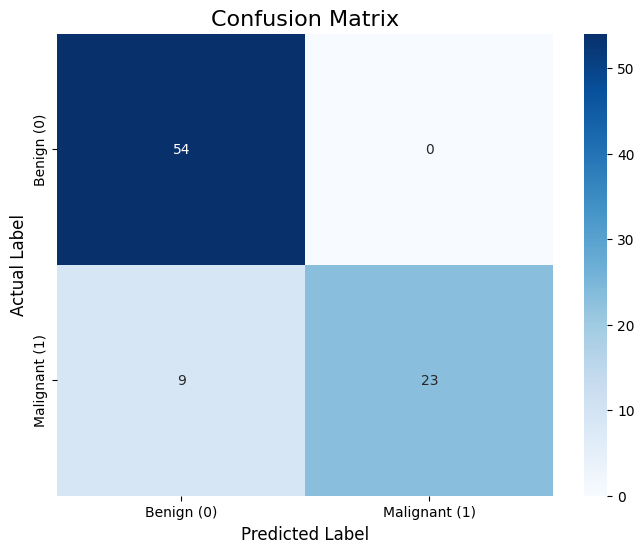


Evaluation complete.


In [9]:
# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Benign (0)", "Malignant (1)"], yticklabels=["Benign (0)", "Malignant (1)"])
plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.show()

print("\nEvaluation complete.")